## Implementing GW in paired and unpaired setting

Does not use all-vs-all point pairs.

In [21]:
import numpy as np
import scipy
import scipy.linalg 
import matplotlib.pyplot as plt

from colors import color_segment
from scipy.optimize import minimize
from scipy.stats import vonmises_fisher
from mpl_toolkits.mplot3d import Axes3D

In [22]:
blue_pink = color_segment()

#### Paired setting

Coupling er fast ($v_a^i$ svarer til $v_b^i$). Vi skal blot finde rotationsmatricen. 

Rotation er en isometri, så den bevarer pr definition de interne afstande.

Rotationmatrix er en unitær matrix: unitært invariant, bevarer normen af vektorer og afstande mellem punkter.

In [2]:
# a class of the estimated rotation matrix
# parameterized by the theta_1,theta_2,theta_3,theta_4
# where theta = [theta_i,...,theta_n]
class RotationMatrix:
    def __init__(self, theta):
        self.theta = theta # Parameters [theta_x, theta_y, theta_z]

    def R(self):
        """Generates an isometry (rotation matrix) using the matrix exponential of a skew-symmetric matrix."""
        tx, ty, tz = self.theta
        A = np.array([[0, -tz, ty],
                      [tz, 0, -tx],
                      [-ty, tx, 0]])
        return scipy.linalg.expm(A)
    
# Geodesic distance
def geodesic_distance_s2(v1, v2):
    """
    Computes geodesic distance between two unit vectors on the unit sphere S^2.
    """
    return np.arccos(np.clip(np.dot(v1, v2), -1.0, 1.0))

In [3]:
# Loss terms:

def intra_alignment_batch(v_a_batch, v_b_batch, num_pairs=10):
    """
    Measures the structural discrepancy between distributions by comparing 
    internal pairwise distances (Gromov-Wasserstein logic).
    """
    losses = []
    N = len(v_a_batch)
    for _ in range(num_pairs):
        i, j = np.random.choice(N, 2, replace=False)
        d_a = geodesic_distance_s2(v_a_batch[i], v_a_batch[j])
        d_b = geodesic_distance_s2(v_b_batch[i], v_b_batch[j])
        losses.append((d_a - d_b)**2)
    return np.mean(losses)

def combined_loss(theta, v_a_batch, v_b_batch, lambda_intra=1.0):
    """
    Combined loss for paired alignment using Lagrangian discretization.
    
    1. Inter-alignment: Minimizes point-to-point transport cost (L2 norm for optimization)
    2. Intra-alignment: Acts as a structural anchor to ensure geometric consistency.
    """
    # 1. Generate rotation matrix R from parameters theta
    rot_obj = RotationMatrix(theta)
    R = rot_obj.R()
    
    # print(v_a_batch.shape, v_b_batch.shape, R.shape)  
    
    # 2. Inter-alignment (Primary driver for learning R in the paired setting)
    # inspired by Gromov-Wasserstein, but in paired and discreate setting.
    # Uses squared L2 norm for stable gradient-based optimization.
    inter_err = np.mean([np.linalg.norm(va - R @ vb)**2 
                         for va, vb in zip(v_a_batch, v_b_batch)])
    
    # 3. Intra-alignment (Gromov-Wasserstein structural anchor)
    # Note: For pure rotations (isometries), the gradient is zero, 
    # but this term ensures the transformation behaves as a rigid rotation.
    intra_err = intra_alignment_batch(v_a_batch, v_b_batch, num_pairs=10)
    
    # 4. Total weighted loss
    return inter_err + (lambda_intra * intra_err)


'''
def rotation_alignment(R):
    # -- might be contratictory, encouraging R to be close to the identity ---
    # ""assign low weight?""
    return np.linalg.norm(R - np.eye(R.shape[0]), ord=2)**2
'''

'\ndef rotation_alignment(R):\n    # -- might be contratictory, encouraging R to be close to the identity ---\n    # ""assign low weight?""\n    return np.linalg.norm(R - np.eye(R.shape[0]), ord=2)**2\n'

In [4]:
# 1. Generate vMF Data
# mu must be a unit vector in R3
mu_a = np.array([1.0, 0.0, 0.0])  
kappa = 20  

# how many point pairs to use for making the data
num_pairs = 10

# Sample target data (Space A)
data_a = vonmises_fisher.rvs(mu_a, kappa, size=num_pairs, random_state=42)

# Create source data (Space B) by applying a ground truth rotation
true_theta = np.array([np.pi/4, 0, 0]) # 45 degrees around X
R_true = RotationMatrix(true_theta).R()
data_b = (R_true.T @ data_a.T).T 

# 2. Learn the Rotation R
initial_theta = np.random.randn(3) * 0.1

result = minimize(
    fun=combined_loss,
    x0=initial_theta,
    args=(data_a, data_b, 0.1),
    method='L-BFGS-B'
)

In [5]:

# 3. Results
learned_theta = result.x
R_learned = RotationMatrix(learned_theta).R()

# Verification: Calculate the remaining angular error
aligned_b = (R_learned @ data_b.T).T
mu_aligned_b = np.mean(aligned_b, axis=0)
mu_aligned_b /= np.linalg.norm(mu_aligned_b)

cos_sim = np.clip(np.dot(mu_a, mu_aligned_b), -1.0, 1.0)
angle_error = np.degrees(np.arccos(cos_sim))

print(f"Learned Theta: {learned_theta}")
print(f"Alignment Error: {angle_error:.4f} degrees")

Learned Theta: [7.85394089e-01 2.64795308e-06 1.59786364e-06]
Alignment Error: 6.1731 degrees


Finished n=2, Mean Error: 13.1818
Finished n=5, Mean Error: 5.4712
Finished n=10, Mean Error: 4.5987
Finished n=50, Mean Error: 2.1491
Finished n=100, Mean Error: 1.6879
Finished n=500, Mean Error: 0.5973


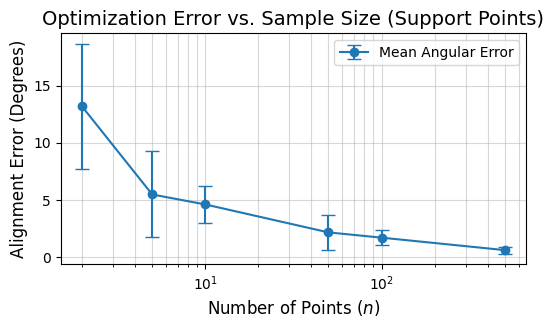

In [6]:
# plot alignment error by the num_points used for making the data

np.random.seed(42)

def run_single_trial(num_points, kappa=20):
    """Performs one optimization run and returns the angular error."""
    mu_a = np.array([1.0, 0.0, 0.0])
    
    # Generate Data
    data_a = vonmises_fisher.rvs(mu_a, kappa, size=num_points)
    true_theta = np.array([np.pi/4, 0, 0]) 
    R_true = RotationMatrix(true_theta).R()
    data_b = (R_true.T @ data_a.T).T 

    # Learn Rotation (Optimization)
    initial_theta = np.random.randn(3) * 0.1
    result = minimize(
        fun=combined_loss,
        x0=initial_theta,
        args=(data_a, data_b, 0.1),
        method='L-BFGS-B'
    )

    # Calculate Alignment Error 
    R_learned = RotationMatrix(result.x).R()
    aligned_b = (R_learned @ data_b.T).T
    mu_aligned_b = np.mean(aligned_b, axis=0)
    mu_aligned_b /= np.linalg.norm(mu_aligned_b)

    cos_sim = np.clip(np.dot(mu_a, mu_aligned_b), -1.0, 1.0)
    return np.degrees(np.arccos(cos_sim))

# --- Main Simulation Loop ---
num_points_range = [2, 5, 10, 50, 100, 500]
iterations_per_n = 10  # repeats for confidence
avg_errors = []
std_errors = []

for n in num_points_range:
    trial_errors = [run_single_trial(n) for _ in range(iterations_per_n)]
    avg_errors.append(np.mean(trial_errors))
    std_errors.append(np.std(trial_errors))
    print(f"Finished n={n}, Mean Error: {avg_errors[-1]:.4f}")

# --- Plotting Results ---
plt.figure(figsize=(6, 3))
plt.errorbar(num_points_range, avg_errors, yerr=std_errors, fmt='-o', capsize=5, label='Mean Angular Error')
plt.xlabel('Number of Points ($n$)', fontsize=12)
plt.ylabel('Alignment Error (Degrees)', fontsize=12)
plt.title('Optimization Error vs. Sample Size (Support Points)', fontsize=14)
plt.xscale('log')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()


^^ Discrete setting, shows *weak convergence* (see Peyre def 2.2). Densities are used to generate data, but then sampling number of points and the experiment is then in the discrete domain. The number of points is higher and thereby describes the data density "cloud" better if more points. 

#### Unpaired setting

No longer pairs -> no longer (implicit; no exactly defined cost but pairs means there is a cost, the one defined in `combined_loss`) cost matrix. 

In unpaired setting: It is a combination issue of an alignment optimal transport problem: We should evaluate distance between every possible pair of points $(i,j)$ across the two spaces to determine the optimal one.

Should learn both the coupling and the rotation matrix (param. by theta).

Even as it is unpaired, when two spheres are matched (same underlying manifold), the optimal solution will be the 1:1 match pairing as this is the least costly solution to match the two distributions (when the weights are uniform). When the distributions are equal in size ($n=m$) and has uniform weights ($1/n$).

Finding an optimal coupling measure that links two continuous densities $\rho_a$ and $\rho_b$

In [7]:
def sinkhorn_algorithm(C, epsilon, a, b, iterations=200):
    """
    Computes the entropic optimal transport coupling P.
    Uses the Gibbs kernel K = exp(-C/epsilon).
    """
    K = np.exp(-C / epsilon)
    u = np.ones(len(a))
    for _ in range(iterations):
        # Iterative scaling to satisfy marginal constraints
        v = b / (K.T @ u)
        u = a / (K @ v)
    return u[:, None] * K * v[None, :]

def compute_cost_matrix(data_a, rotated_data_b):
    """
    Calculates the pairwise cost matrix Ci,j = c(xi, yj).
    Evaluated on the full support of the source and target measures.
    """
    # Squared Euclidean distance is the standard ground cost for W2
    diff = data_a[:, np.newaxis, :] - rotated_data_b[np.newaxis, :, :]
    return np.sum(diff**2, axis=2)

def transport_objective(theta, data_a, data_b, P):
    """
    Objective function minimizing the transport cost <C, P>.
    Learns the alignment (theta) for a fixed matching (P).
    """
    R_curr = RotationMatrix(theta).R()
    # Apply rotation as a push-forward operator
    rotated_b = (R_curr @ data_b.T).T
    C = compute_cost_matrix(data_a, rotated_b)
    return np.sum(C * P) # Frobenius dot-product

# --- Experiment Parameters ---
np.random.seed(120)
n_samples = 200  # High sample size to approximate continuous densities
epsilon = 0.01   # Regularization parameter for the Sinkhorn matching
mu_a = np.array([1.0, 0.0, 0.0])
kappa = 20

# 1. Generate Continuous Distributions (via Empirical Sampling)
# These points serve as the support for our measures alpha and beta
data_a = vonmises_fisher.rvs(mu_a, kappa, size=n_samples)
true_theta = np.array([np.pi/4, 0, 0]) 
R_true = RotationMatrix(true_theta).R()
data_b = (R_true.T @ data_a.T).T 
np.random.shuffle(data_b) # Unpaired setting: correspondences are unknown

# Probability weights (histograms) must sum to 1
a = np.ones(n_samples) / n_samples
b = np.ones(n_samples) / n_samples

# 2. Alternating Optimization Loop
# We alternate between finding the best matching and the best alignment
theta_est = np.random.randn(3) * 0.1

for epoch in range(15):
    # Step A: Matching (Solve for optimal coupling P)
    # This addresses the Kantorovich problem given the current theta
    R_curr = RotationMatrix(theta_est).R()
    current_rotated_b = (R_curr @ data_b.T).T
    C = compute_cost_matrix(data_a, current_rotated_b)
    P = sinkhorn_algorithm(C, epsilon, a, b)
    
    # Step B: Alignment (Solve for optimal rotation theta)
    # This optimizes the spatial shift given the current matching
    res = minimize(
        fun=transport_objective,
        x0=theta_est,
        args=(data_a, data_b, P),
        method='L-BFGS-B'
    )
    theta_est = res.x
    
    # Verification: Calculate first-order moment alignment (Angular Error)
    R_learned = RotationMatrix(theta_est).R()
    aligned_b = (R_learned @ data_b.T).T
    mu_aligned_b = np.mean(aligned_b, axis=0)
    mu_aligned_b /= np.linalg.norm(mu_aligned_b)
    cos_sim = np.clip(np.dot(mu_a, mu_aligned_b), -1.0, 1.0)
    angle_error = np.degrees(np.arccos(cos_sim))
    
    print(f"Epoch {epoch}: Angular Error = {angle_error:.4f} degrees, Estimated Theta = {np.round(theta_est, 3)}")

print(f"\nFinal Learned Alignment: {np.round(theta_est, 4)}")
print(f"Original Ground Truth:  {np.round(true_theta, 4)}")

Epoch 0: Angular Error = 1.1791 degrees, Estimated Theta = [ 0.072 -0.014 -0.005]
Epoch 1: Angular Error = 1.1807 degrees, Estimated Theta = [ 0.084 -0.013 -0.005]
Epoch 2: Angular Error = 1.1823 degrees, Estimated Theta = [ 0.096 -0.013 -0.005]
Epoch 3: Angular Error = 1.1840 degrees, Estimated Theta = [ 0.11  -0.013 -0.005]
Epoch 4: Angular Error = 1.1859 degrees, Estimated Theta = [ 0.126 -0.013 -0.005]
Epoch 5: Angular Error = 1.1878 degrees, Estimated Theta = [ 0.143 -0.012 -0.005]
Epoch 6: Angular Error = 1.1898 degrees, Estimated Theta = [ 0.162 -0.012 -0.005]
Epoch 7: Angular Error = 1.1920 degrees, Estimated Theta = [ 0.183 -0.012 -0.004]
Epoch 8: Angular Error = 1.1942 degrees, Estimated Theta = [ 0.207 -0.011 -0.004]
Epoch 9: Angular Error = 1.1960 degrees, Estimated Theta = [ 0.234 -0.011 -0.004]
Epoch 10: Angular Error = 1.1972 degrees, Estimated Theta = [ 0.266 -0.01  -0.004]
Epoch 11: Angular Error = 1.1979 degrees, Estimated Theta = [ 0.301 -0.01  -0.003]
Epoch 12: Angu

might be local minima

In [8]:
def sinkhorn_algorithm(C, epsilon, a, b, iterations=100):
    K = np.exp(-C / epsilon)
    u = np.ones(len(a))
    for _ in range(iterations):
        v = b / (K.T @ u)
        u = a / (K @ v)
    return u[:, None] * K * v[None, :]

def compute_internal_distances(data):
    # Calculates the internal geometry (intra-space distances)
    diff = data[:, np.newaxis, :] - data[np.newaxis, :, :]
    return np.sqrt(np.sum(diff**2, axis=2))

def structural_cost_matrix(data_a, data_b):
    # GW Logic: Compare how point i in A 'sees' its world vs point j in B
    dist_a = compute_internal_distances(data_a)
    dist_b = compute_internal_distances(data_b)
    
    # Cost(i,j) = difference in their relationship to all other points
    # This is a simplified structural matching kernel
    C_structural = np.zeros((len(data_a), len(data_b)))
    for i in range(len(data_a)):
        for j in range(len(data_b)):
            # Compare the sorted neighbor distances for a structural profile
            C_structural[i, j] = np.sum((np.sort(dist_a[i]) - np.sort(dist_b[j]))**2)
    return C_structural

def alignment_objective(theta, data_a, data_b, P):
    R_curr = RotationMatrix(theta).R()
    rotated_b = (R_curr @ data_b.T).T
    # Coordinate-based cost for final alignment
    C = np.sum((data_a[:, np.newaxis, :] - rotated_b[np.newaxis, :, :])**2, axis=2)
    return np.sum(C * P)

# --- GW-Inspired Experiment ---
np.random.seed(42)
n_samples = 100
mu_a = np.array([1.0, 0.0, 0.0])
data_a = vonmises_fisher.rvs(mu_a, kappa=20, size=n_samples)

true_theta = np.array([np.pi/4, 0, 0])
data_b = (RotationMatrix(true_theta).R().T @ data_a.T).T 
np.random.shuffle(data_b) # Unpaired

# Step 1: Structural Matching (GW Phase)
# We find P based on geometry, NOT on current rotation
C_struct = structural_cost_matrix(data_a, data_b)
P_structural = sinkhorn_algorithm(C_struct, epsilon=0.01, 
                                  a=np.ones(n_samples)/n_samples, 
                                  b=np.ones(n_samples)/n_samples)

# Step 2: Alignment (Optimization Phase)
# Now that we have a structurally sound P, we learn the rotation
res = minimize(alignment_objective, np.zeros(3), args=(data_a, data_b, P_structural))
theta_est = res.x

print(f"Final Learned Theta: {np.round(theta_est, 4)}")
print(f"Ground Truth Theta: {np.round(true_theta, 4)}")

Final Learned Theta: [ 0.7854 -0.      0.    ]
Ground Truth Theta: [0.7854 0.     0.    ]


^^ This is essentially the Kantorovich problem solved!! ^^

#### GW unpaired: Matching a 2-sphere with scaled 2-sphere on z-coordinates (ellipsoid)

In [15]:
from scipy.sparse.csgraph import dijkstra
from sklearn.neighbors import kneighbors_graph

def compute_geodesic_intra_distance(data, mode='sphere', k_neighbors=10):
    """
    Computes the intra-space distance matrix D using geodesics.
    For the sphere, it uses the exact arc-length formula.
    For the ellipsoid, it approximates geodesics using a k-NN graph and Dijkstra.
    """
    n = len(data)
    
    if mode == 'sphere':
        # Exact geodesic distance on S2: d(x,y) = arccos(<x, y>)
        # Ensure points are normalized to unit length
        norms = np.linalg.norm(data, axis=1, keepdims=True)
        data_norm = data / norms
        dot_product = np.clip(np.dot(data_norm, data_norm.T), -1.0, 1.0)
        return np.arccos(dot_product)
        
    elif mode == 'ellipsoid':
        # Approximate geodesics via Shortest Path Metric on a k-NN graph
        knn_graph = kneighbors_graph(data, k_neighbors, mode='distance', include_self=False)
        
        # Compute all-pairs shortest paths
        dist_matrix = dijkstra(csgraph=knn_graph, directed=False)
        
        # Handle potential disconnected components by falling back to Euclidean distance
        inf_mask = np.isinf(dist_matrix)
        if np.any(inf_mask):
            diff = data[:, np.newaxis, :] - data[np.newaxis, :, :]
            euclidean_fallback = np.sqrt(np.sum(diff**2, axis=2))
            dist_matrix[inf_mask] = euclidean_fallback[inf_mask]
            
        return dist_matrix

def gromov_wasserstein_sinkhorn(D_src, D_tgt, a, b, epsilon, max_iter=10):
    """
    Computes the Gromov-Wasserstein coupling matrix P using entropic regularization.
    Iteratively linearizes the quadratic assignment problem into Sinkhorn updates.
    """
    n, m = len(a), len(b)
    # Initialize coupling as the product of marginals
    P = a[:, np.newaxis] @ b[np.newaxis, :]
    
    for _ in range(max_iter):
        # Linearization step: Compute the gradient of the GW loss
        # C = - D_src @ P @ D_tgt
        cost_gradient = - np.matmul(np.matmul(D_src, P), D_tgt)
        
        # Sinkhorn step: Solve for the entropic optimal coupling of the gradient
        kernel = np.exp(-cost_gradient / epsilon)
        u = np.ones(n)
        for _ in range(30):
            v = b / (kernel.T @ u)
            u = a / (kernel @ v)
        P = u[:, np.newaxis] * kernel * v[np.newaxis, :]
        
    return P

def compute_gw_loss(D_src, D_tgt, P):
    """
    Computes the final Gromov-Wasserstein distance (structural discrepancy).
    Measures how well pairwise distances are preserved under the coupling P.
    """
    n, m = P.shape
    a, b = np.sum(P, axis=1), np.sum(P, axis=0)
    
    # Efficient matrix formulation of the GW loss
    C1 = np.dot(np.dot(D_src**2, a[:, None]), np.ones((1, m)))
    C2 = np.dot(np.ones((n, 1)), np.dot(b[None, :], (D_tgt**2).T))
    cost_matrix = C1 + C2 - 2 * np.dot(D_src, np.dot(P, D_tgt))
    
    return np.sum(cost_matrix * P)

# --- Experiment Setup ---
def run_alignment_experiment():
    np.random.seed(42)
    n_samples = 120
    epsilon = 0.05
    
    # Generate Source Data (vMF distribution on a Sphere)
    mu_src = np.array([1.0, 0.0, 0.0])
    data_src = vonmises_fisher.rvs(mu_src, kappa=25, size=n_samples)

    # Target Data (Deformed Ellipsoid + Rotation)
    # 1. Start with the same points
    data_tgt = data_src.copy()
    # 2. Stretch the Z-axis
    data_tgt[:, 2] *= 0.4 
    # 3. Apply a ground truth rotation
    theta_true = np.array([np.pi/3, 0.0, 0.0])
    R_true = RotationMatrix(theta_true).R()
    data_tgt = (R_true @ data_tgt.T).T
    # 4. Shuffle to create an unpaired setting
    np.random.shuffle(data_tgt)

    # Compute intrinsic geometries
    D_src = compute_geodesic_intra_distance(data_src, mode='sphere')
    D_tgt = compute_geodesic_intra_distance(data_tgt, mode='ellipsoid')
    
    # Uniform weights for both measures
    a = np.ones(n_samples) / n_samples
    b = np.ones(n_samples) / n_samples
    
    # Learn the structural coupling P using GW
    P_learned = gromov_wasserstein_sinkhorn(D_src, D_tgt, a, b, epsilon)


    # When P is fixed, we find the rotation that minimizes coordinate cost
    def alignment_objective(theta, x_src, y_tgt, coupling_P):
        R_curr = RotationMatrix(theta).R()
        rotated_tgt = (R_curr @ y_tgt.T).T
        # Calculate pairwise Euclidean cost based on current rotation
        diff = x_src[:, np.newaxis, :] - rotated_tgt[np.newaxis, :, :]
        C = np.sum(diff**2, axis=2)
        return np.sum(C * coupling_P)

    res = minimize(alignment_objective, np.zeros(3), args=(data_src, data_tgt, P_learned))
    theta_est = res.x

    # Step E: Results and Evaluation
    gw_dist = compute_gw_loss(D_src, D_tgt, P_learned)
    
    print("--- Experiment Results ---")
    print(f"Learned Theta (est): {np.round(theta_est, 4)}")
    print(f"Ground Truth Theta:  {np.round(theta_true, 4)}")
    print(f"Final GW Distance:   {gw_dist:.6f}")
    print("--------------------------")
    return data_src, data_tgt, P_learned, theta_est, gw_dist

In [17]:
data_src, data_tgt, P_learned, theta_est, gw_dist = run_alignment_experiment()

--- Experiment Results ---
Learned Theta (est): [-1.5292 -0.0186 -0.0256]
Ground Truth Theta:  [1.0472 0.     0.    ]
Final GW Distance:   0.066399
--------------------------


In [29]:
# plot the 2sphere and the ellipsoid, and the learned alignment


def plot_geometric_alignment(data_src, data_tgt, theta_est, stretch_z):
    # Calculate the aligned target points using the learned rotation
    R_final = RotationMatrix(theta_est).R()
    aligned_tgt = (R_final @ data_tgt.T).T
    
    fig = plt.figure(figsize=(18, 6))
    
    def draw_mesh(ax, stretch=1.0, rotation=None):
        u, v = np.linspace(0, 2*np.pi, 30), np.linspace(0, np.pi, 30)
        x = np.outer(np.cos(u), np.sin(v))
        y = np.outer(np.sin(u), np.sin(v))
        z = np.outer(np.ones(np.size(u)), np.cos(v)) * stretch
        
        if rotation is not None:
            mesh_pts = np.stack([x.flatten(), y.flatten(), z.flatten()])
            rotated = rotation @ mesh_pts
            x = rotated[0, :].reshape(30, 30)
            y = rotated[1, :].reshape(30, 30)
            z = rotated[2, :].reshape(30, 30)
            
        ax.plot_surface(x, y, z, cmap=blue_pink, alpha=0.1, linewidth=0, antialiased=True)
        # Use a tuple of (1, 1, 1) to make the sphere look round
        ax.set_box_aspect((1, 1, 1)) 
        
        # Ensure identical axis limits to prevent automatic stretching
        ax.set_xlim([-1.2, 1.2])
        ax.set_ylim([-1.2, 1.2])
        ax.set_zlim([-1.2, 1.2])

    # 1. Plot: Source Sphere
    ax1 = fig.add_subplot(131, projection='3d')
    draw_mesh(ax1)
    ax1.scatter(data_src[:, 0], data_src[:, 1], data_src[:, 2], color='blue', s=20)
    ax1.set_title("Source: 2-Sphere")
    ax1.axis('off')

    # 2. Plot: Target Ellipsoid
    ax2 = fig.add_subplot(132, projection='3d')
    R_true_mesh = RotationMatrix(np.array([np.pi/3, 0.0, 0.0])).R() 
    draw_mesh(ax2, stretch=stretch_z, rotation=R_true_mesh)
    ax2.scatter(data_tgt[:, 0], data_tgt[:, 1], data_tgt[:, 2], color='red', s=20, alpha=0.6)
    ax2.set_title("Target: Deformed & Rotated")
    ax2.axis('off')

    # 3. Plot: Final Alignment
    ax3 = fig.add_subplot(133, projection='3d')
    draw_mesh(ax3)
    # Plot original source in light blue as reference
    ax3.scatter(data_src[:, 0], data_src[:, 1], data_src[:, 2], color='blue', s=20, alpha=0.2)
    # Plot transformed target in solid red - if aligned, they should hit the blue spots
    ax3.scatter(aligned_tgt[:, 0], aligned_tgt[:, 1], aligned_tgt[:, 2], color='red', s=15)
    ax3.set_title("GW Alignment Result")
    ax3.axis('off')

    plt.tight_layout()
    plt.show()


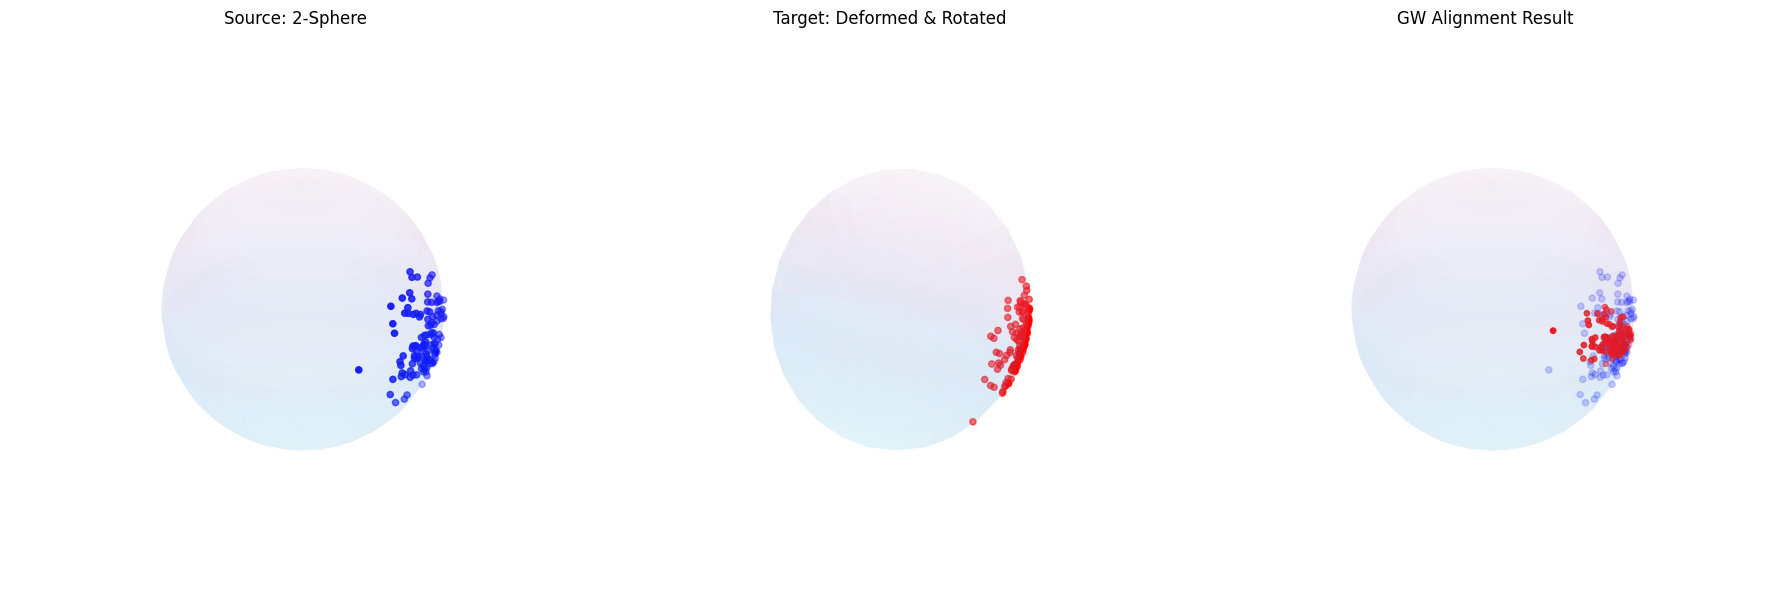

In [30]:
plot_geometric_alignment(data_src, data_tgt, theta_est, stretch_z=0.4)

In [11]:
def recover_rotation_from_coupling(data_src, data_tgt, P):
    """
    Given a fixed coupling P from GW, finds the rotation theta 
    that minimizes the standard coordinate-based transport cost.
    """
    def objective(theta):
        R_curr = RotationMatrix(theta).R()
        rotated_tgt = (R_curr @ data_tgt.T).T
        # Inter-space coordinate cost
        C = np.sum((data_src[:, np.newaxis, :] - rotated_tgt[np.newaxis, :, :])**2, axis=2)
        return np.sum(C * P)

    res = minimize(objective, np.zeros(3))
    return res.x